Kütüphaneler başarıyla yüklendi. TensorFlow sürümü: 2.19.0
Veriler üretiliyor...
Eğitim verisi boyutu: (500, 128, 128, 1)
U-Net Mimarisi Başarıyla Kuruldu!
Eğitim başlıyor...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9014 - loss: 0.3634 - val_accuracy: 0.9978 - val_loss: 0.0063
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9982 - loss: 0.0044 - val_accuracy: 0.9986 - val_loss: 0.0036
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9989 - loss: 0.0030 - val_accuracy: 0.9991 - val_loss: 0.0024
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9992 - loss: 0.0022 - val_accuracy: 0.9993 - val_loss: 0.0020
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 993ms/step - accuracy: 0.9994 - loss: 0.0017 - val_accuracy: 0.9996 - val_loss: 0.0014
Eğitim tamamlandı. Modelin başarı grafikleri çizdiriliyor...


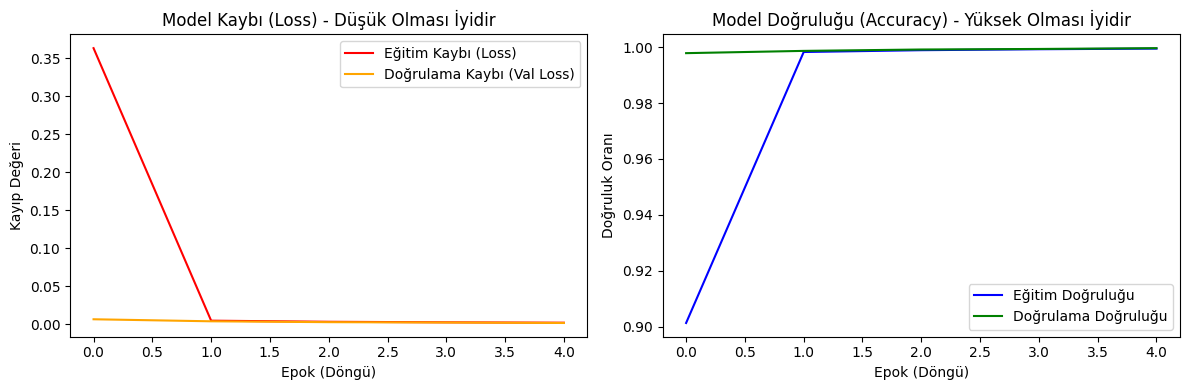


--- SONUÇ ---
Test Verisi Üzerindeki Başarı (Accuracy): %99.96
U-Net Segmentasyon Modeli Başarıyla Eğitildi ve Değerlendirildi.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print("Kütüphaneler başarıyla yüklendi. TensorFlow sürümü:", tf.__version__)


def generate_synthetic_data(num_samples, img_size=128):

    images = np.zeros((num_samples, img_size, img_size, 1), dtype=np.float32)
    masks = np.zeros((num_samples, img_size, img_size, 1), dtype=np.float32)

    for i in range(num_samples):
        r = np.random.randint(10, 30)
        x = np.random.randint(r, img_size - r)
        y = np.random.randint(r, img_size - r)

        Y, X = np.ogrid[:img_size, :img_size]
        dist_from_center = np.sqrt((X - x)**2 + (Y - y)**2)

        mask = dist_from_center <= r
        images[i, mask, 0] = 1.0
        masks[i, mask, 0] = 1.0

        noise = np.random.rand(img_size, img_size, 1) * 0.2
        images[i] = np.clip(images[i] + noise, 0, 1)

    return images, masks

print("Veriler üretiliyor...")
X_train, y_train = generate_synthetic_data(500)
X_test, y_test = generate_synthetic_data(50)
print(f"Eğitim verisi boyutu: {X_train.shape}")


def build_unet(input_shape=(128, 128, 1)):
    inputs = layers.Input(shape=input_shape)


    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)


    b = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)


    u1 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(b)
    merge1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(merge1)

    u2 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c3)
    merge2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(merge2)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c4)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

model = build_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("U-Net Mimarisi Başarıyla Kuruldu!")

print("Eğitim başlıyor...")
history = model.fit(X_train, y_train, epochs=5, batch_size=16, validation_data=(X_test, y_test))

# -----------------------------------------
# 4. EĞİTİM SONUÇLARI VE GRAFİKLER (MASK GÖRSELLEŞTİRME YOK)
# -----------------------------------------
print("Eğitim tamamlandı. Modelin başarı grafikleri çizdiriliyor...")

plt.figure(figsize=(12, 4))

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı (Loss)', color='red')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Val Loss)', color='orange')
plt.title('Model Kaybı (Loss) - Düşük Olması İyidir')
plt.xlabel('Epok (Döngü)')
plt.ylabel('Kayıp Değeri')
plt.legend()

# Başarı (Accuracy) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu', color='blue')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu', color='green')
plt.title('Model Doğruluğu (Accuracy) - Yüksek Olması İyidir')
plt.xlabel('Epok (Döngü)')
plt.ylabel('Doğruluk Oranı')
plt.legend()

plt.tight_layout()
plt.show()

# Modelin Test Verisi Üzerindeki Nihai Başarısı
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n--- SONUÇ ---")
print(f"Test Verisi Üzerindeki Başarı (Accuracy): %{test_acc*100:.2f}")
print("U-Net Segmentasyon Modeli Başarıyla Eğitildi ve Değerlendirildi.")